In [10]:
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd

### Let's make a better OHLC chart
---
Get the base data

In [11]:
with sqlite3.connect('stocks.db') as con:
    stock_raw_df = pd.read_sql_query(
        con=con,
        sql="""
        SELECT
            date,
            open,
            high,
            low,
            close,
            volume,
            ema_5,
            ema_10,
            ema_20,
            upper_channel,
            lower_channel,
            macd_histogram,
            impulse
        FROM
            daily
        WHERE
            symbol = 'LEG'
            AND date >= date('now', '-366 day')
        ORDER BY
            date
        """
    )

    weekly_raw_df = pd.read_sql_query(
        con=con,
        sql="""
        SELECT
            dly.date,
            week.ema_5,
            week.ema_10,
            week.ema_20,
            CASE 
                WHEN week.ema_5 < week.ema_10 AND week.ema_10 < week.ema_20 THEN TRUE
                ELSE FALSE
            END AS 'weekly_red_shader',
            CASE 
                WHEN week.ema_5 > week.ema_10 AND week.ema_10 > week.ema_20 THEN TRUE
                ELSE FALSE
            END AS 'weekly_green_shader',
            CASE 
                WHEN dly.ema_5 < dly.ema_10 AND dly.ema_10 < dly.ema_20 THEN TRUE
                ELSE FALSE
            END AS 'daily_red_shader',
            CASE 
                WHEN dly.ema_5 > dly.ema_10 AND dly.ema_10 > dly.ema_20 THEN TRUE
                ELSE FALSE
            END AS 'daily_green_shader'
        FROM
            weekly week
        INNER JOIN
            daily dly
                ON week.symbol = dly.symbol
                AND dly.date BETWEEN week.date AND date(week.date, '+5 day')
        WHERE
            week.symbol = 'LEG'
            AND week.date >= date('now', '-365 day')
        """
    )

    bom_df = pd.read_sql_query(
        con=con,
        sql="""
            SELECT
                year,
                month,
                min(date) AS 'BOM'
            FROM
                calendar
            WHERE
                day_of_week < 5
                AND NOT is_market_holiday
                AND date >= date('now', '-365 day')
            GROUP BY
                1,2
            ORDER BY
                3 DESC
            LIMIT 12
        """
    )

### MACD Histogram
---

In [12]:
negative_but_rising = '#9B4D4C'
negative_but_falling = '#720000'
postive_but_rising = '#0D0D0D'
positive_but_falling = '#999999'

In [13]:
hist_df = stock_raw_df.copy()
hist_df['yest_hist'] = hist_df['macd_histogram'].shift(1)
hist_df = hist_df.dropna(subset=['yest_hist'])
hist_df['color'] = ''

hist_df.loc[(hist_df['macd_histogram'] < 0) & (hist_df['macd_histogram'] > hist_df['yest_hist']), 'color'] = negative_but_rising
hist_df.loc[(hist_df['macd_histogram'] < 0) & (hist_df['macd_histogram'] <= hist_df['yest_hist']), 'color'] = negative_but_falling
hist_df.loc[(hist_df['macd_histogram'] > 0) & (hist_df['macd_histogram'] >= hist_df['yest_hist']), 'color'] = postive_but_rising
hist_df.loc[(hist_df['macd_histogram'] > 0) & (hist_df['macd_histogram'] < hist_df['yest_hist']), 'color'] = positive_but_falling

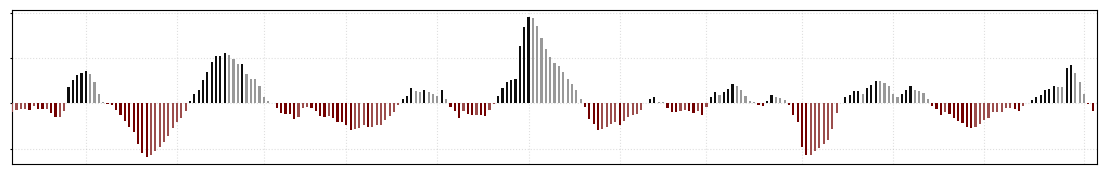

In [14]:
fig, ax = plt.subplots(figsize=(14,2))

ax.bar(x=hist_df['date'], height=hist_df['macd_histogram'], width=.5, color=hist_df['color'], zorder=3)
ax.grid(visible=True, linestyle=':', alpha=.4, zorder=0)
ax.set_xticks(bom_df['BOM'])
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.tick_params(axis='x', direction='in', length=0)
ax.tick_params(axis='y', direction='out', length=1.5)
ax.set_xbound(lower=0, upper=len(hist_df))

### OHLC Chart
---

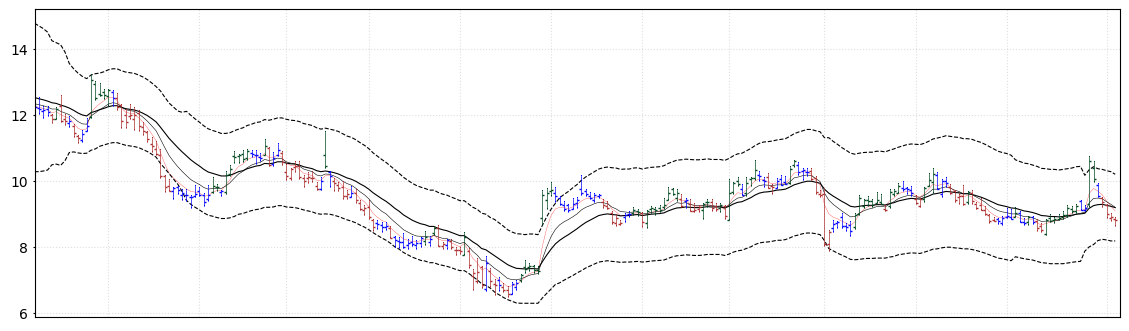

In [15]:
ohlc_df = hist_df.copy().drop(columns=['macd_histogram', 'yest_hist', 'color']).reset_index(drop=True)
ohlc_df['impulse'] = ohlc_df['impulse'].map({'Green': '#004820', 'Blue': '#0000FF', 'Red': '#AC2E2E'})

fig, ax = plt.subplots(figsize=(14,4))

ax.plot(ohlc_df['date'], ohlc_df['ema_5'], linestyle='-', color='red', linewidth=.2)
ax.plot(ohlc_df['date'], ohlc_df['ema_10'], linestyle='-', color='black', linewidth=.4)
ax.plot(ohlc_df['date'], ohlc_df['ema_20'], linestyle='-', color='black', linewidth=.8)
ax.plot(ohlc_df['date'], ohlc_df['upper_channel'], linestyle='--', color='black', linewidth=.8)
ax.plot(ohlc_df['date'], ohlc_df['lower_channel'], linestyle='--', color='black', linewidth=.8)

for i in range(len(ohlc_df)):
    date = ohlc_df['date'][i]
    high = ohlc_df['high'][i]
    low = ohlc_df['low'][i]
    open = ohlc_df['open'][i]
    close = ohlc_df['close'][i]
    color = ohlc_df['impulse'][i]
    
    ax.plot([date, date], [low, high], marker=',', linestyle='-', color=color, linewidth=.5)
    ax.plot(date, open, marker=0, color=color, markersize=1.5)
    ax.plot(date, close, marker=1, color=color, markersize=1.5)



ax.set_xbound(lower=0, upper=len(ohlc_df))
ax.grid(visible=True, linestyle=':', alpha=.4, zorder=0)
ax.set_xticks(bom_df['BOM'])
ax.set_xticklabels([])
ax.tick_params(axis='x', direction='in', length=0)
ax.tick_params(axis='y', direction='out', length=1.5)
plt.show()

### Need to be aware of weekly trend alignment
---

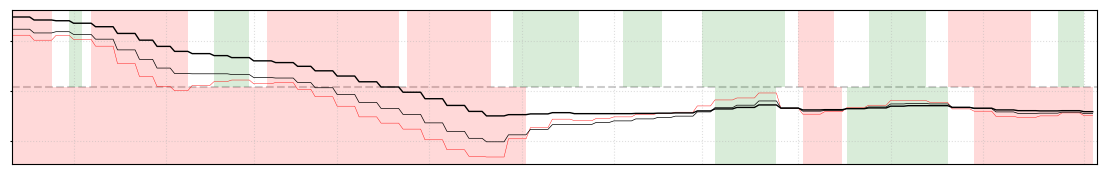

In [16]:
fig, ax = plt.subplots(figsize=(14,2))

ax.grid(visible=True, linestyle=':', alpha=.4, zorder=0)
ax.plot(weekly_raw_df['date'], weekly_raw_df['ema_5'], color='r', linewidth=.3)
ax.plot(weekly_raw_df['date'], weekly_raw_df['ema_10'], color='k', linewidth=.5)
ax.plot(weekly_raw_df['date'], weekly_raw_df['ema_20'], color='k', linewidth=1)
ax.set_xticks(bom_df['BOM'])
ax.tick_params(axis='x', direction='in', length=0)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.tick_params(axis='y', direction='out', length=1.5)


min_y = min(ax.get_ybound())
max_y = max(ax.get_ybound())

ax.fill_between(
    weekly_raw_df['date'], 
    min_y, 
    (min_y+max_y)/2, 
    alpha=.15, 
    color='r',
    edgecolor=None,
    where=weekly_raw_df['weekly_red_shader']
)

ax.fill_between(
    weekly_raw_df['date'], 
    min_y, 
    (min_y+max_y)/2, 
    alpha=.15, 
    color='g',
    edgecolor=None,
    where=weekly_raw_df['weekly_green_shader']
)


ax.fill_between(
    weekly_raw_df['date'], 
    (min_y+max_y)/2, 
    max_y,
    alpha=.15, 
    color='r',
    edgecolor=None,
    where=weekly_raw_df['daily_red_shader']
)

ax.fill_between(
    weekly_raw_df['date'], 
    (min_y+max_y)/2, 
    max_y, 
    alpha=.15, 
    color='g',
    edgecolor=None,
    where=weekly_raw_df['daily_green_shader']
)

ax.hlines(y=(min_y+max_y)/2, xmin=0, xmax=len(weekly_raw_df), zorder=0, linestyles='dashed', alpha=.2, color='k')
ax.set_ybound(min_y, max_y)
ax.set_xbound(lower=0, upper=len(weekly_raw_df))

plt.show()

In [17]:
max_y

13.251000000000001

In [18]:
weekly_raw_df.to_csv('testing.csv', index=False)